In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer


In [ ]:
OBS = '../02_data/2026-05-28_compendium/qwen'

In [4]:
stop = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')
stemmer = PorterStemmer()


def lexical_overlap(s1, s2, stopword_removal=True, use_stemmer=True):
    s1 = tokenizer.tokenize(s1.lower().strip())
    s2 = tokenizer.tokenize(s2.lower().strip())

    if use_stemmer == True:
        s1 = [stemmer.stem(w) for w in s1]
        s2 = [stemmer.stem(w) for w in s2]

    words1, words2 = set(s1), set(s2)
    if stopword_removal == True:
        words1, words2 = words1 - stop, words2 - stop
        

    if min(len(words1), len(words2)) == 0:
        return 0
    
    overlap = len(words1 & words2) / min(len(words1), len(words2))
    return overlap

In [5]:
def lexical_match(s1: str, s2: str, method: str = "overlap") -> float:
    return lexical_overlap(s1, s2)

In [6]:
results = {}

for id in os.listdir(OBS):
    if id == '.DS_Store':
        continue
    info = id.split('_')
    retriever = info[3]

    df = pd.read_json(f"{OBS}/{id}/results.jsonl", orient='records', lines=True)
    
    df['lexical_overlap'] = df.apply(lambda item: lexical_match(item['input'], item['answer'], "overlap"), axis=1)
    df['lexical_overlap_answers'] = df.apply(lambda item: lexical_match(item['answer'], item['generated_answer'], "overlap"), axis=1)

    results[f"{retriever}"] = df

In [7]:
results['hybrid'][['task_success_score', 'lexical_overlap', 'retriever_recall@10']]

,task_success_score,lexical_overlap,retriever_recall@10
0,5,1.000000,0.040000
1,9,0.600000,0.333333
2,0,0.571429,0.375000
3,5,0.714286,1.000000
4,5,1.000000,0.428571
...,...,...,...
593,5,0.400000,0.666667
594,5,0.500000,0.571429
595,6,0.600000,0.800000
596,6,0.500000,0.500000


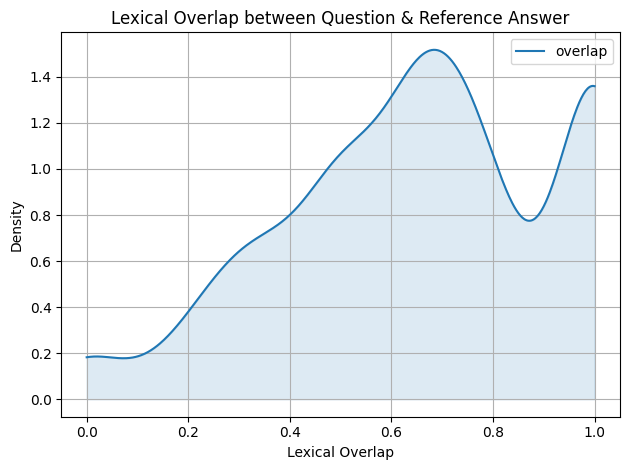

In [8]:
fig, ax = plt.subplots()
x_grid = np.linspace(0, 1, 500)

df = results['sparse']
values = df["lexical_overlap"].dropna().values
kde = gaussian_kde(values)
density = kde(x_grid)


p = ax.plot(x_grid, density, label='overlap')
color = p[-1].get_color()
ax.fill_between(x_grid, density, alpha=0.15, color=color)

ax.set_xlabel("Lexical Overlap")
ax.set_ylabel("Density")
ax.set_title("Lexical Overlap between Question & Reference Answer")
ax.legend()
ax.grid()
fig.tight_layout()

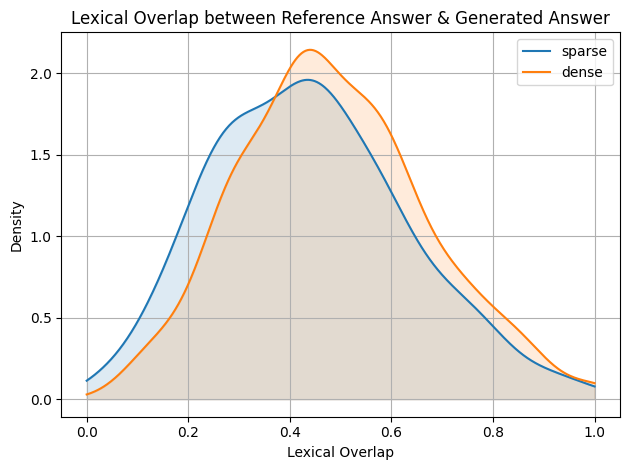

In [9]:
fig, ax = plt.subplots()
x_grid = np.linspace(0, 1, 500)

for key in ['sparse', 'dense']:
    df = results[key]
    values = df["lexical_overlap_answers"].dropna().values
    kde = gaussian_kde(values)
    density = kde(x_grid)

    p = ax.plot(x_grid, density, label=key)
    color = p[-1].get_color()
    ax.fill_between(x_grid, density, alpha=0.15, color=color)

ax.set_xlabel("Lexical Overlap")
ax.set_ylabel("Density")
ax.set_title("Lexical Overlap between Reference Answer & Generated Answer")
ax.legend()
ax.grid()
fig.tight_layout()

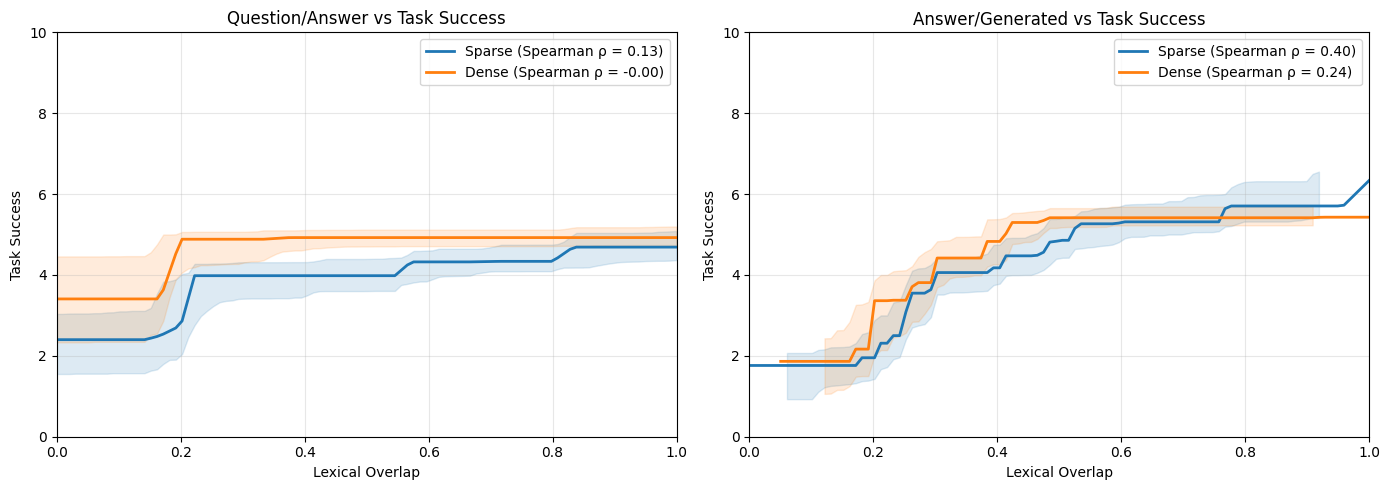

In [10]:
from sklearn.isotonic import IsotonicRegression

def bootstrap_isotonic_ci(
    x: np.ndarray,
    y: np.ndarray,
    x_line: np.ndarray,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    y_min: float = 0,
    y_max: float = 10,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit isotonic regression with bootstrapped confidence intervals.

    Parameters
    ----------
    x            : 1D predictor values (e.g. overlap scores)
    y            : target values (e.g. task_success_score)
    x_line       : points at which to evaluate the fitted curve
    n_bootstrap  : number of bootstrap resamples
    ci           : confidence level, e.g. 0.95 for 95% CI
    y_min/y_max  : bounds passed to IsotonicRegression

    Returns
    -------
    ci_lower, ci_upper : arrays of shape (len(x_line),)
    """
    rng = np.random.default_rng(random_state)
    preds = np.empty((n_bootstrap, len(x_line)))

    for i in range(n_bootstrap):
        idx = rng.integers(0, len(x), size=len(x))   # resample with replacement
        iso = IsotonicRegression(y_min=y_min, y_max=y_max)
        iso.fit(x[idx], y[idx])
        preds[i] = iso.predict(x_line)

    alpha = (1 - ci) / 2
    ci_lower = np.quantile(preds, alpha, axis=0)
    ci_upper = np.quantile(preds, 1 - alpha, axis=0)
    return ci_lower, ci_upper

def plot_overlap(fig, ax1, results, overlap, title):
    x_line = np.linspace(0, 1, 100)

    for retriever in ['sparse', 'dense']:
        df = results[retriever]
        corr = df[overlap].corr(df["task_success_score"], method='spearman')

        iso_reg = IsotonicRegression(y_min=0, y_max=10).fit(df[overlap], df["task_success_score"])
        y_line  = iso_reg.predict(x_line)
        ci_lower, ci_upper = bootstrap_isotonic_ci(df[overlap].values, df["task_success_score"].values, x_line)

        p = ax1.plot(x_line, y_line, linewidth=2, label=f"{retriever.capitalize()} (Spearman ρ = {corr:.2f})")
        color = p[-1].get_color()
        ax1.fill_between(x_line, ci_lower, ci_upper, color=color, alpha=0.15)

    ax1.set_title(title)
    ax1.set_xlabel("Lexical Overlap")
    ax1.set_ylabel("Task Success")
    ax1.set_ylim(0, 10)
    ax1.set_xlim(0, 1)
    ax1.legend()
    ax1.grid(True, alpha=0.3)


def plot_lexical_overlap(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    plot_overlap(fig, axes[0], results, 'lexical_overlap', 'Question/Answer vs Task Success')
    plot_overlap(fig, axes[1], results, 'lexical_overlap_answers', 'Answer/Generated vs Task Success')


    # plot_overlap(fig, axes[1], df, 'lexical_overlap_answers', f'{retriever.capitalize()}: Answer / Generated')

    plt.tight_layout()
    plt.show()

plot_lexical_overlap(results)

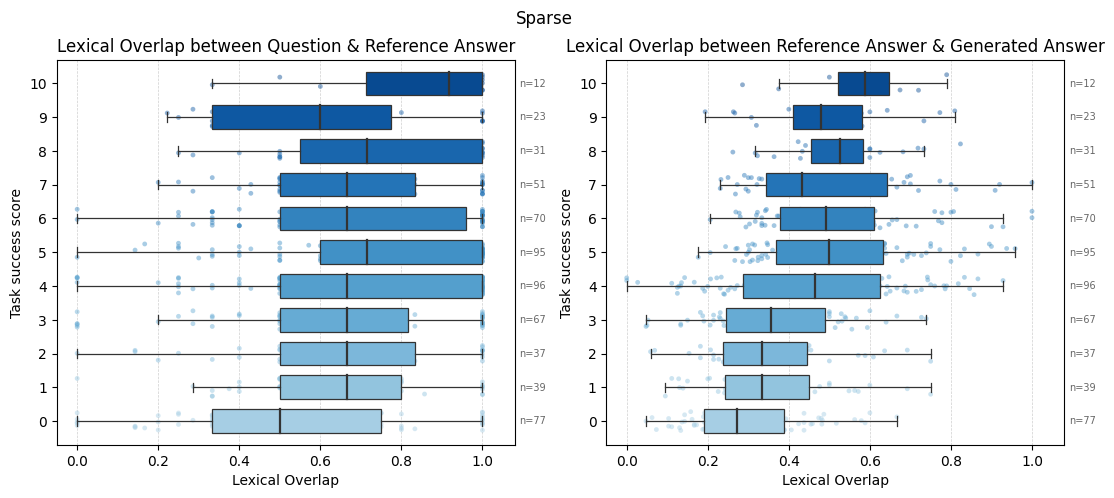

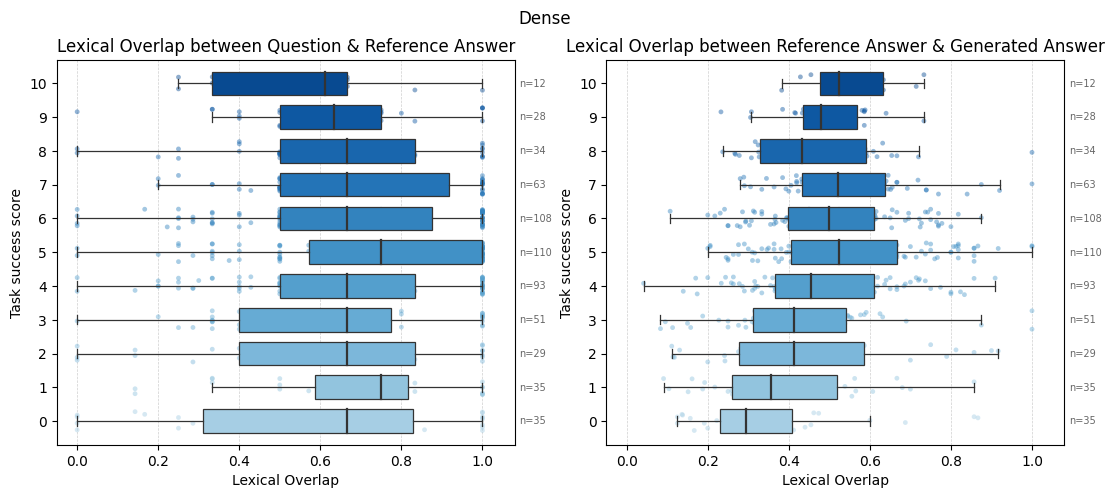

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np


COL_SUCCESS  = "task_success_score"
COL_Q_REF    = "lexical_overlap"
COL_REF_GEN  = "lexical_overlap_answers"
 
 


def plot_overlap_per_task_success(df, retriever):
    scores = sorted(df[COL_SUCCESS].unique().astype(int))
    n_scores = len(scores)

    cmap   = plt.cm.Blues
    colors = [cmap(0.35 + 0.55 * i / max(n_scores - 1, 1)) for i in range(n_scores)]
    
    fig, axes = plt.subplots(1, 2,figsize=(13, 5))
    
    plot_cfg = [
        (axes[0], COL_Q_REF,   "Lexical Overlap between Question & Reference Answer"),
        (axes[1], COL_REF_GEN, "Lexical Overlap between Reference Answer & Generated Answer"),
    ]
    
    for ax, col, title in plot_cfg:
        for i, score in enumerate(scores):
            vals = df.loc[df[COL_SUCCESS] == score, col].values
            y = score
            color = colors[i]
    
            q1, med, q3 = np.percentile(vals, [25, 50, 75])
            iqr = q3 - q1
            w_lo = max(vals[vals >= q1 - 1.5 * iqr].min(), vals.min())
            w_hi = min(vals[vals <= q3 + 1.5 * iqr].max(), vals.max())
            bh = 0.35
    
            box = plt.Polygon(
                [[q1, y - bh], [q3, y - bh], [q3, y + bh], [q1, y + bh]],
                closed=True, facecolor=color, edgecolor="#333333",
                linewidth=0.9, zorder=3,
            )
            ax.add_patch(box)
            ax.plot([med, med], [y - bh, y + bh], color="#333333", linewidth=1.6, zorder=4)
    
            ax.plot([w_lo, q1], [y, y], color="#333333", linewidth=0.9, zorder=3)
            ax.plot([q3, w_hi], [y, y], color="#333333", linewidth=0.9, zorder=3)
            ax.plot([w_lo, w_lo], [y - bh * 0.4, y + bh * 0.4], color="#333333", linewidth=0.9, zorder=3)
            ax.plot([w_hi, w_hi], [y - bh * 0.4, y + bh * 0.4], color="#333333", linewidth=0.9, zorder=3)
    
            rng    = np.random.default_rng(score)
            jitter = rng.uniform(-bh * 0.8, bh * 0.8, size=len(vals))
            ax.scatter(vals, y + jitter, s=12, color=color, alpha=0.45, edgecolors="none", zorder=2)
    
            ax.text(1.01, y, f"n={len(vals)}", va="center", ha="left", fontsize=7, color="#666666", transform=ax.get_yaxis_transform())
    
        ax.set_yticks(scores)
        ax.set_yticklabels(scores)
        ax.set_ylim(min(scores) - 0.7, max(scores) + 0.7)
        ax.set_xlim(-0.05, 1.08)
        ax.set_xlabel("Lexical Overlap")
        ax.set_ylabel("Task success score")
        ax.set_title(title)
        ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)

    plt.suptitle(retriever)
    plt.show()

df = results['sparse'][[COL_SUCCESS, COL_Q_REF, COL_REF_GEN]].dropna()
plot_overlap_per_task_success(df, 'Sparse')

df = results['dense'][[COL_SUCCESS, COL_Q_REF, COL_REF_GEN]].dropna()
plot_overlap_per_task_success(df, 'Dense')

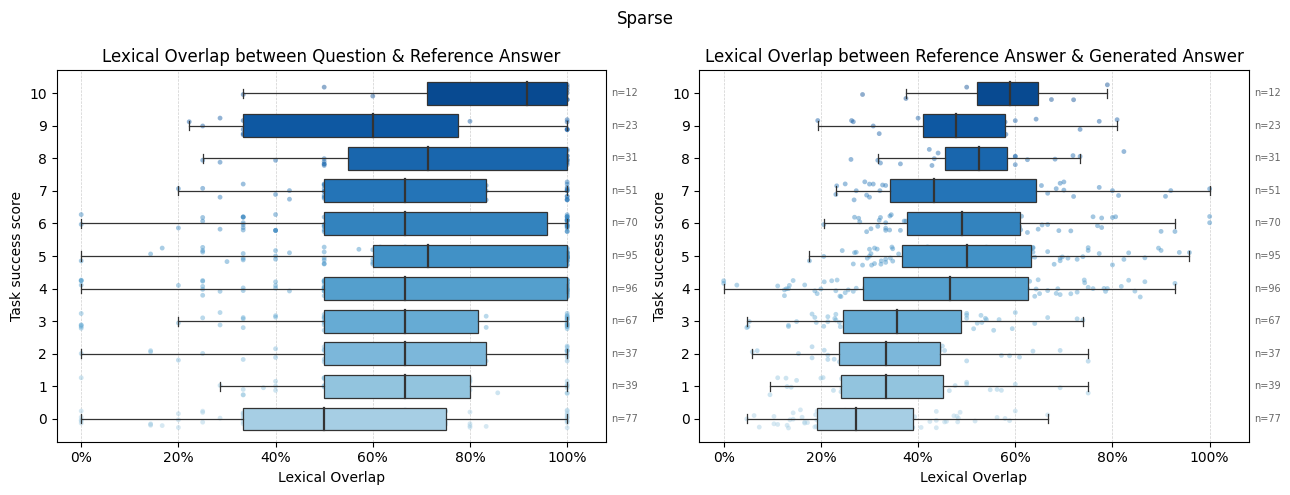

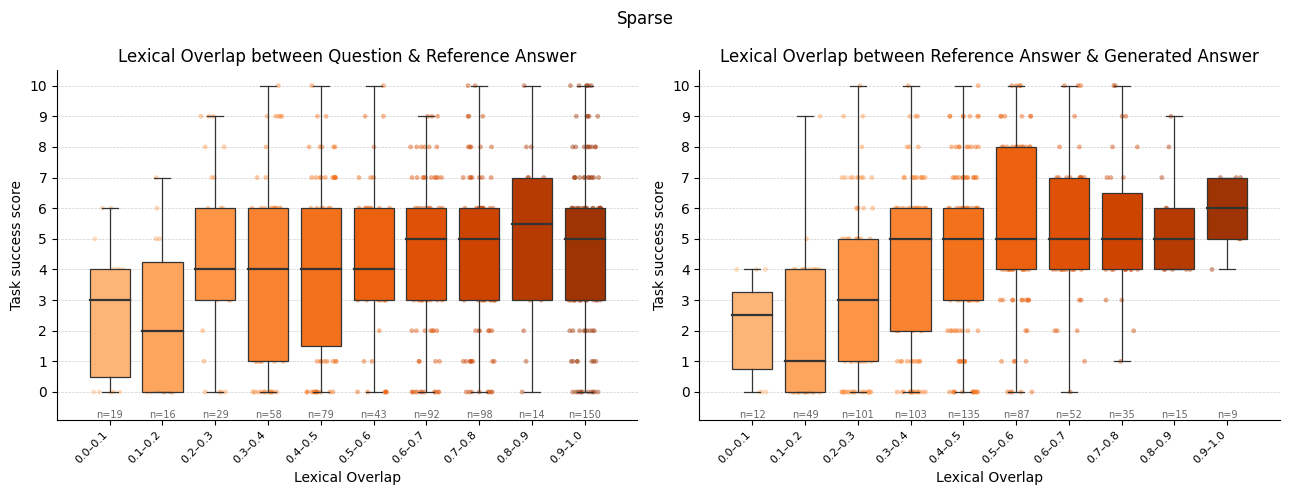

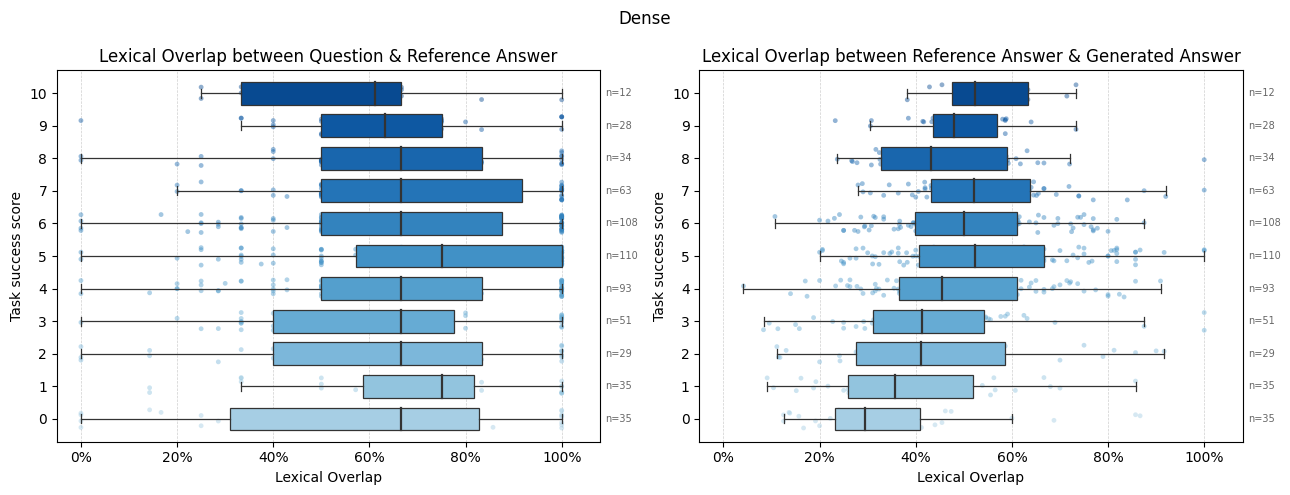

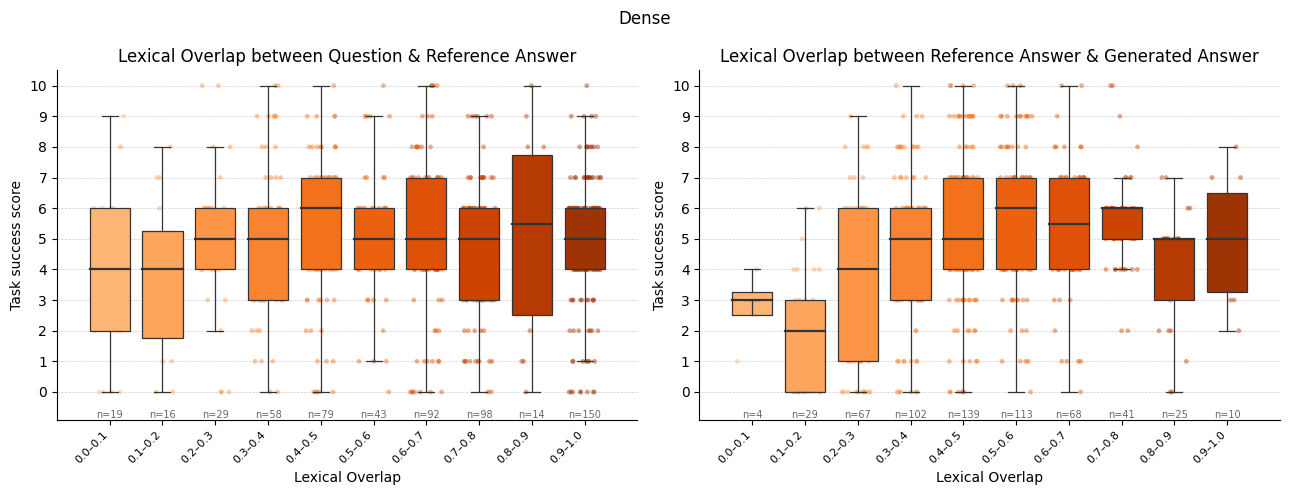

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


COL_SUCCESS  = "task_success_score"
COL_Q_REF    = "lexical_overlap"
COL_REF_GEN  = "lexical_overlap_answers"


def _draw_horizontal_boxes(ax, df, col, group_col, groups, colors, bh=0.35):
    """Draw horizontal boxplot + strip for each group on ax."""
    for i, grp in enumerate(groups):
        vals = df.loc[df[group_col] == grp, col].values
        if len(vals) < 2:
            continue
        y, color = grp, colors[i]

        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr  = q3 - q1
        w_lo = max(vals[vals >= q1 - 1.5 * iqr].min(), vals.min())
        w_hi = min(vals[vals <= q3 + 1.5 * iqr].max(), vals.max())

        box = plt.Polygon(
            [[q1, y - bh], [q3, y - bh], [q3, y + bh], [q1, y + bh]],
            closed=True, facecolor=color, edgecolor="#333333",
            linewidth=0.9, zorder=3,
        )
        ax.add_patch(box)
        ax.plot([med, med], [y - bh, y + bh], color="#333333", linewidth=1.6, zorder=4)
        ax.plot([w_lo, q1], [y, y], color="#333333", linewidth=0.9, zorder=3)
        ax.plot([q3, w_hi], [y, y], color="#333333", linewidth=0.9, zorder=3)
        ax.plot([w_lo, w_lo], [y - bh * 0.4, y + bh * 0.4], color="#333333", linewidth=0.9, zorder=3)
        ax.plot([w_hi, w_hi], [y - bh * 0.4, y + bh * 0.4], color="#333333", linewidth=0.9, zorder=3)

        rng    = np.random.default_rng(i)
        jitter = rng.uniform(-bh * 0.8, bh * 0.8, size=len(vals))
        ax.scatter(vals, y + jitter, s=12, color=color, alpha=0.45, edgecolors="none", zorder=2)
        ax.text(1.01, y, f"n={len(vals)}", va="center", ha="left",
                fontsize=7, color="#666666", transform=ax.get_yaxis_transform())


def plot_overlap_per_task_success(df, retriever):
    """Boxplots grouped by task success score (one row per score)."""
    scores   = sorted(df[COL_SUCCESS].unique().astype(int))
    n_scores = len(scores)
    cmap     = plt.cm.Blues
    colors   = [cmap(0.35 + 0.55 * i / max(n_scores - 1, 1)) for i in range(n_scores)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plot_cfg = [
        (axes[0], COL_Q_REF,   "Lexical Overlap between Question & Reference Answer"),
        (axes[1], COL_REF_GEN, "Lexical Overlap between Reference Answer & Generated Answer"),
    ]

    for ax, col, title in plot_cfg:
        _draw_horizontal_boxes(ax, df, col, COL_SUCCESS, scores, colors)
        ax.set_yticks(scores)
        ax.set_yticklabels(scores)
        ax.set_ylim(min(scores) - 0.7, max(scores) + 0.7)
        ax.set_xlim(-0.05, 1.08)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_xlabel("Lexical Overlap")
        ax.set_ylabel("Task success score")
        ax.set_title(title)
        ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)

    plt.suptitle(retriever)
    plt.tight_layout()
    plt.show()


def plot_success_per_overlap_bin(df, retriever, n_bins=10):
    """
    For each lexical overlap bin (x-axis), show the distribution of
    task success scores (y-axis) as a vertical boxplot + strip.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plot_cfg = [
        (axes[0], COL_Q_REF,   "Lexical Overlap between Question & Reference Answer"),
        (axes[1], COL_REF_GEN, "Lexical Overlap between Reference Answer & Generated Answer"),
    ]

    cmap = plt.cm.Oranges

    for ax, col, title in plot_cfg:
        bin_edges   = np.linspace(0, 1, n_bins + 1)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width   = bin_edges[1] - bin_edges[0]
        bin_labels  = [f"{bin_edges[j]:.1f}–{bin_edges[j+1]:.1f}" for j in range(n_bins)]

        df_binned        = df[[COL_SUCCESS, col]].copy()
        df_binned["bin"] = pd.cut(df_binned[col], bins=bin_edges,
                                  labels=np.arange(n_bins), include_lowest=True).astype(float)
        df_binned = df_binned.dropna(subset=["bin"])

        occupied = sorted(df_binned["bin"].unique().astype(int))
        colors   = [cmap(0.35 + 0.55 * i / max(len(occupied) - 1, 1)) for i in range(len(occupied))]

        hw = bin_width * 0.38   # half-width of each box

        for i, b in enumerate(occupied):
            vals  = df_binned.loc[df_binned["bin"] == b, COL_SUCCESS].values
            x     = bin_centers[b]
            color = colors[i]

            if len(vals) < 2:
                continue

            q1, med, q3 = np.percentile(vals, [25, 50, 75])
            iqr  = q3 - q1
            w_lo = max(vals[vals >= q1 - 1.5 * iqr].min(), vals.min())
            w_hi = min(vals[vals <= q3 + 1.5 * iqr].max(), vals.max())

            # Vertical box (x = overlap position, y = task success)
            box = plt.Polygon(
                [[x - hw, q1], [x - hw, q3], [x + hw, q3], [x + hw, q1]],
                closed=True, facecolor=color, edgecolor="#333333",
                linewidth=0.9, zorder=3,
            )
            ax.add_patch(box)
            ax.plot([x - hw, x + hw], [med, med],
                    color="#333333", linewidth=1.6, zorder=4)
            ax.plot([x, x], [w_lo, q1], color="#333333", linewidth=0.9, zorder=3)
            ax.plot([x, x], [q3, w_hi], color="#333333", linewidth=0.9, zorder=3)
            ax.plot([x - hw * 0.4, x + hw * 0.4], [w_lo, w_lo],
                    color="#333333", linewidth=0.9, zorder=3)
            ax.plot([x - hw * 0.4, x + hw * 0.4], [w_hi, w_hi],
                    color="#333333", linewidth=0.9, zorder=3)

            rng    = np.random.default_rng(b)
            jitter = rng.uniform(-hw * 0.8, hw * 0.8, size=len(vals))
            ax.scatter(x + jitter, vals, s=12, color=color,
                       alpha=0.45, edgecolors="none", zorder=2)

            ax.text(x, -0.6, f"n={len(vals)}", ha="center", va="top",
                    fontsize=7, color="#666666")

        scores = sorted(df[COL_SUCCESS].unique().astype(int))
        ax.set_yticks(scores)
        ax.set_yticklabels(scores)
        ax.set_ylim(min(scores) - 0.9, max(scores) + 0.5)
        ax.set_xlim(-0.05, 1.05)
        ax.set_xticks(bin_centers[occupied])
        ax.set_xticklabels([bin_labels[b] for b in occupied],
                           rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("Lexical Overlap")
        ax.set_ylabel("Task success score")
        ax.set_title(title)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle(retriever)
    plt.tight_layout()
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
for retriever_key, label in [("sparse", "Sparse"), ("dense", "Dense")]:
    df = results[retriever_key][[COL_SUCCESS, COL_Q_REF, COL_REF_GEN]].dropna()
    plot_overlap_per_task_success(df, label)
    plot_success_per_overlap_bin(df, label, n_bins=10)   # change n_bins as needed

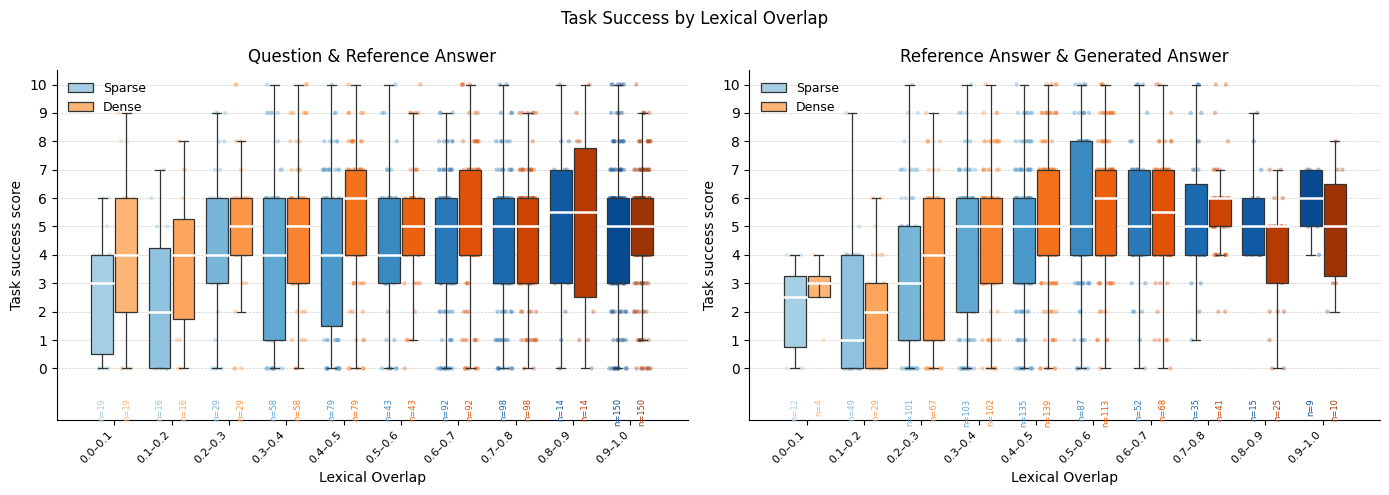

In [13]:
def _draw_vertical_box(ax, x, vals, hw, color, label=None):
    """Draw a single vertical box+whisker+strip at position x."""
    if len(vals) < 2:
        return
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr  = q3 - q1
    w_lo = max(vals[vals >= q1 - 1.5 * iqr].min(), vals.min())
    w_hi = min(vals[vals <= q3 + 1.5 * iqr].max(), vals.max())

    box = plt.Polygon(
        [[x - hw, q1], [x - hw, q3], [x + hw, q3], [x + hw, q1]],
        closed=True, facecolor=color, edgecolor="#333333",
        linewidth=0.9, zorder=3, label=label,
    )
    ax.add_patch(box)
    ax.plot([x - hw, x + hw], [med, med], color="white", linewidth=1.8, zorder=4)
    ax.plot([x, x], [w_lo, q1], color="#333333", linewidth=0.9, zorder=3)
    ax.plot([x, x], [q3, w_hi], color="#333333", linewidth=0.9, zorder=3)
    ax.plot([x - hw * 0.4, x + hw * 0.4], [w_lo, w_lo],
            color="#333333", linewidth=0.9, zorder=3)
    ax.plot([x - hw * 0.4, x + hw * 0.4], [w_hi, w_hi],
            color="#333333", linewidth=0.9, zorder=3)

    rng    = np.random.default_rng(int(x * 1000))
    jitter = rng.uniform(-hw * 0.8, hw * 0.8, size=len(vals))
    ax.scatter(x + jitter, vals, s=10, color=color,
               alpha=0.35, edgecolors="none", zorder=2)


def plot_combined_success_per_overlap_bin(results_dict, retriever_keys, labels, colors, n_bins=10):
    """
    Side-by-side vertical boxplots per overlap bin, one pair per retriever.
    Task success score on y-axis, lexical overlap bins on x-axis.

    Parameters
    ----------
    results_dict   : the full results dict
    retriever_keys : list of keys to compare, e.g. ["sparse", "dense"]
    labels         : display names,              e.g. ["Sparse", "Dense"]
    colors         : one color per retriever,    e.g. ["#4C72B0", "#DD8452"]
    n_bins         : number of equal-width overlap bins
    """
    n_ret = len(retriever_keys)

    bin_edges   = np.linspace(0, 1, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width   = bin_edges[1] - bin_edges[0]
    bin_labels  = [f"{bin_edges[j]:.1f}–{bin_edges[j+1]:.1f}" for j in range(n_bins)]

    # hw so boxes from all retrievers fit inside one bin with a small gap
    hw    = bin_width * 0.38 / n_ret
    gap   = bin_width * 0.04
    total = n_ret * 2 * hw + (n_ret - 1) * gap
    offsets = [-(total / 2) + i * (2 * hw + gap) + hw for i in range(n_ret)]

    # Pre-bin all dataframes
    binned = {}
    for key in retriever_keys:
        df = results_dict[key][[COL_SUCCESS, COL_Q_REF, COL_REF_GEN]].dropna().copy()
        for col in [COL_Q_REF, COL_REF_GEN]:
            df[f"bin_{col}"] = pd.cut(df[col], bins=bin_edges,
                                      labels=np.arange(n_bins),
                                      include_lowest=True).astype(float)
        binned[key] = df

    # All scores across retrievers for shared y-axis
    all_scores = sorted(set(
        int(s)
        for key in retriever_keys
        for s in binned[key][COL_SUCCESS].unique()
    ))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_cfg = [
        (axes[0], COL_Q_REF,   "Question & Reference Answer"),
        (axes[1], COL_REF_GEN, "Reference Answer & Generated Answer"),
    ]

    for ax, col, title in plot_cfg:
        bin_col = f"bin_{col}"
        occupied = sorted(set(
            int(b)
            for key in retriever_keys
            for b in binned[key][bin_col].dropna().unique()
        ))

        for i, (key, label, cmap) in enumerate(zip(retriever_keys, labels, colors)):
            df_b = binned[key]
            first_box = True   # only add legend label once per retriever


            c = [cmap(0.35 + 0.55 * i / max(len(occupied) - 1, 1)) for i in range(len(occupied))]
            for n, b in enumerate(occupied):
                vals = df_b.loc[df_b[bin_col] == b, COL_SUCCESS].values
                x    = bin_centers[b] + offsets[i]
                _draw_vertical_box(ax, x, vals, hw, c[n], label=label if first_box else None)
                first_box = False

                # n= label below each box
                if len(vals) > 0:
                    ax.text(x, min(all_scores) - 1.05, f"n={len(vals)}", ha="center", va="top", fontsize=6, color=c[n], rotation=90)

        ax.set_yticks(all_scores)
        ax.set_yticklabels(all_scores)
        ax.set_ylim(min(all_scores) - 1.8, max(all_scores) + 0.5)
        ax.set_xlim(bin_edges[occupied[0]] - bin_width * 0.5, bin_edges[occupied[-1] + 1] + bin_width * 0.5)
        ax.set_xticks(bin_centers[occupied])
        ax.set_xticklabels([bin_labels[b] for b in occupied], rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("Lexical Overlap")
        ax.set_ylabel("Task success score")
        ax.set_title(title)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=9, loc="upper left")

    plt.suptitle("Task Success by Lexical Overlap")
    plt.tight_layout()
    plt.show()

plot_combined_success_per_overlap_bin(
    results,
    retriever_keys=["sparse", "dense"],
    labels=["Sparse", "Dense"],
    colors=[plt.cm.Blues, plt.cm.Oranges],
    n_bins=10,
)


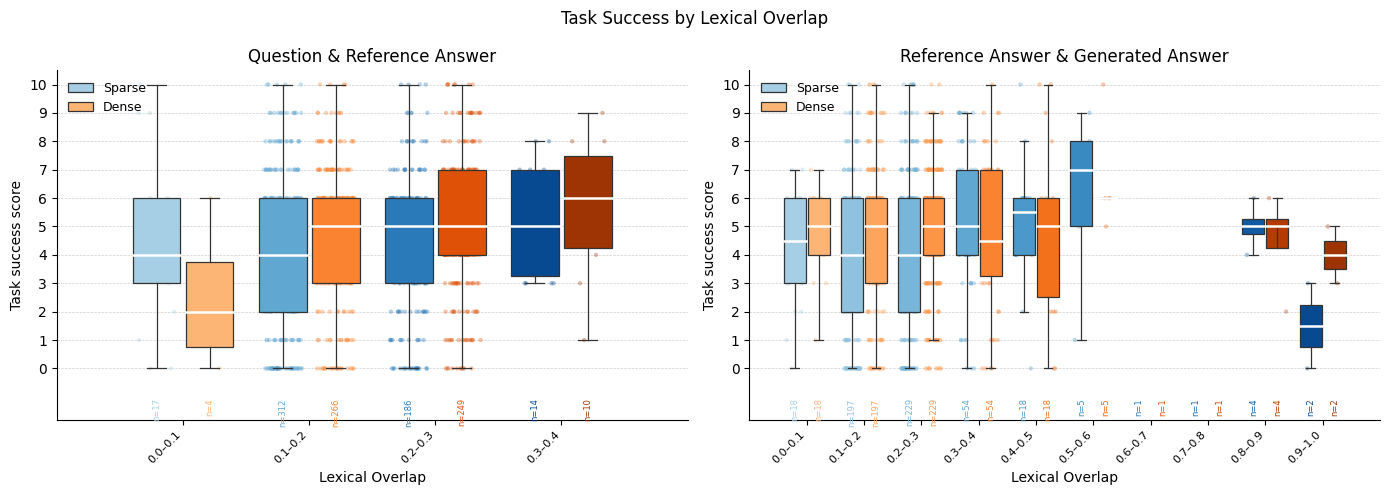

In [14]:

from itertools import combinations

def set_lexical_match(paragraphs):
    texts = [d["text"] for d in paragraphs]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    scores = [lexical_match(a, b, method='overlap') for a, b in pairs]
    return np.mean(scores)

for k in results.keys():

    df = results[k]
    df['lex_retrieved'] = df['retrieved'].apply(set_lexical_match)
    df['lex_reference'] = df['reference'].apply(set_lexical_match)

COL_SUCCESS  = "task_success_score"
COL_Q_REF    = "lex_retrieved"
COL_REF_GEN  = "lex_reference"

plot_combined_success_per_overlap_bin(
    results,
    retriever_keys=["sparse", "dense"],
    labels=["Sparse", "Dense"],
    colors=[plt.cm.Blues, plt.cm.Oranges],
    n_bins=10,
)
